**Chargement de MNIST**

In [1]:
from tensorflow.keras.datasets import mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Prétraitement des données 

In [2]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)


Construction du CNN

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilation du modèle 

In [4]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Évaluation du modéle

In [5]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.2
)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 51s 33ms/step - accuracy: 0.8859 - loss: 0.3496 - val_accuracy: 0.9803 - val_loss: 0.0641
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9836 - loss: 0.0508 - val_accuracy: 0.9861 - val_loss: 0.0484
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9914 - loss: 0.0279 - val_accuracy: 0.9837 - val_loss: 0.0567
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 32ms/step - accuracy: 0.9933 - loss: 0.0218 - val_accuracy: 0.9872 - val_loss: 0.0435
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 47s 31ms/step - accuracy: 0.9957 - loss: 0.0145 - val_accuracy: 0.9903 - val_loss: 0.0383
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9963 - loss: 0.0117 - val_accuracy: 0.9864 - val_loss: 0.0502
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 33ms/step - accuracy: 0.9969 - loss: 0.0088 - val_accuracy: 0.9910 - val_loss: 0.0369
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 78s 31ms/step - accuracy: 0.9969 -

Visualisation des résultats

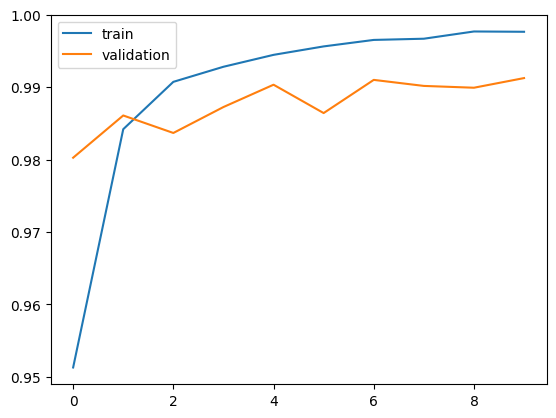

In [6]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()


Test sur des images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


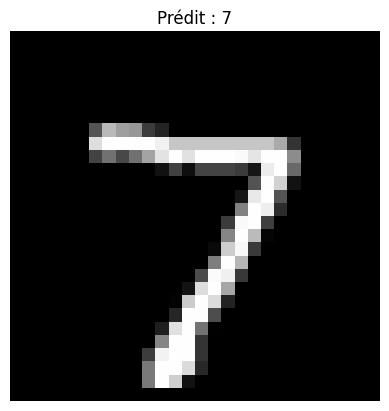

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


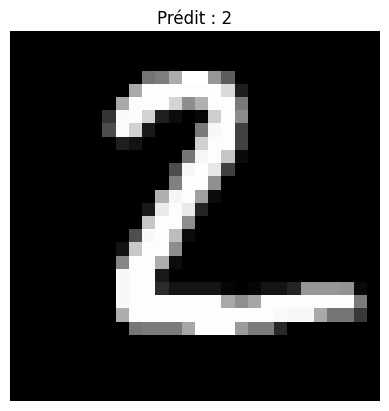

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


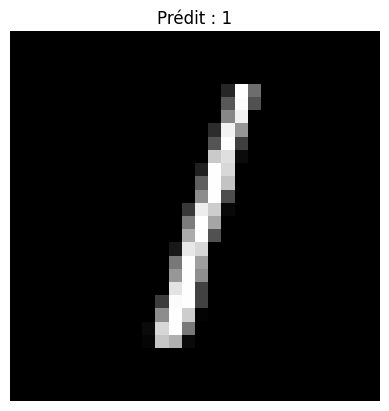

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


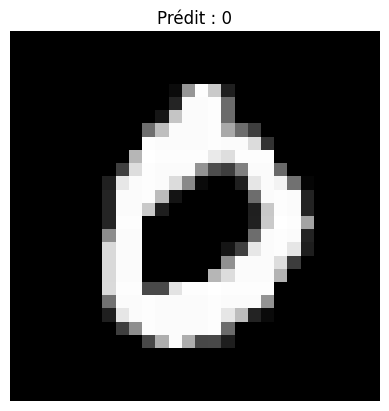

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


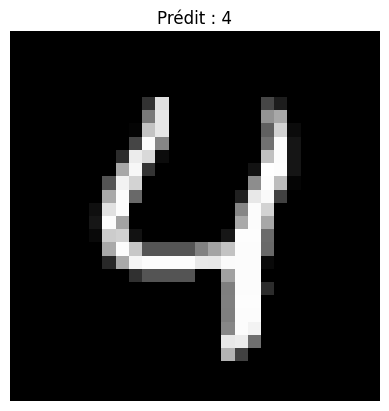

In [8]:
import numpy as np
import matplotlib.pyplot as plt

for i in range(5):
    img = x_test[i].reshape(1,28,28,1)
    pred = model.predict(img)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Prédit : {np.argmax(pred)}")
    plt.axis('off')
    plt.show()



sauvegarde du modèle 

In [9]:
model.save("cnn_mnist_model.h5")
